In [10]:
from torchvision.datasets import EuroSAT
import matplotlib.pyplot as plt
import random
import os
import pandas as pd 
import numpy as np
from sklearn.model_selection import train_test_split

In [40]:
config = {
    'dir' : '/Users/user/projects/eurosat',
    'data' : 'data/eurosat/2750', 
    'rseed' : 19
}

pd.set_option("display.max_colwidth", None )

In [4]:
# download data
ds = EuroSAT(root=os.path.join(config['dir'], 'data'), download=True)
print(len(ds), ds.classes)

27000 ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


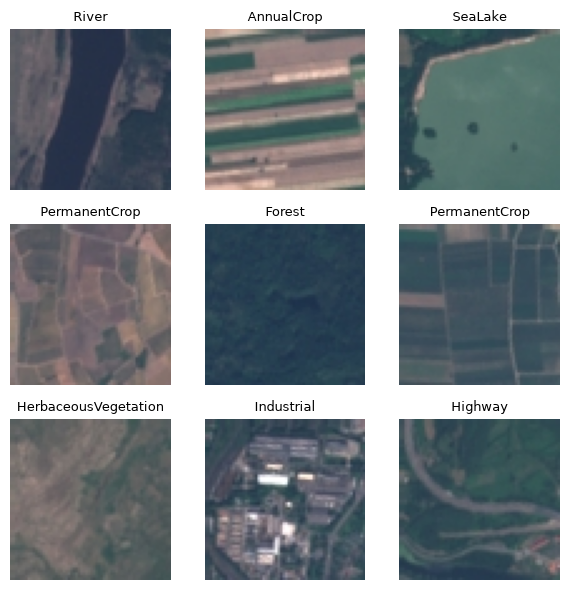

In [6]:
random.seed(config['rseed'])
idxs = random.sample(range(len(ds)), 9)

fig, axes = plt.subplots(3, 3, figsize=(6, 6))
for ax, i in zip(axes.flat, idxs):
    img, label = ds[i]
    ax.imshow(img)
    ax.set_title(ds.classes[label], fontsize=9)
    ax.axis("off")
plt.tight_layout()
plt.show()

## Understanding the Data

Questions:
1. How many images per category


In [7]:
out = "num. images per class:"
for i in range(len(ds.classes) - 1):
    out += f"\n  {ds.classes[i]}: \t{len(os.listdir(os.path.join(config['dir'], config['data'], ds.classes[i])))}"

print(out)


num. images per class:
  AnnualCrop: 	3000
  Forest: 	3000
  HerbaceousVegetation: 	3000
  Highway: 	2500
  Industrial: 	2500
  Pasture: 	2000
  PermanentCrop: 	2500
  Residential: 	3000
  River: 	2500


In [63]:
# df of indices of data with strata
strata_cols = ["strata_id", "strata_name"]
strata = dict(enumerate(ds.classes))

cols = ["file_path", "strata_id"]
data_indices = pd.DataFrame(ds.samples, columns=cols)
data_indices["strata_name"] = data_indices["strata_id"].map(strata)

data_indices.tail()

,file_path,strata_id,strata_name
26995,/Users/user/projects/eurosat/data/eurosat/2750/SeaLake/SeaLake_995.jpg,9,SeaLake
26996,/Users/user/projects/eurosat/data/eurosat/2750/SeaLake/SeaLake_996.jpg,9,SeaLake
26997,/Users/user/projects/eurosat/data/eurosat/2750/SeaLake/SeaLake_997.jpg,9,SeaLake
26998,/Users/user/projects/eurosat/data/eurosat/2750/SeaLake/SeaLake_998.jpg,9,SeaLake
26999,/Users/user/projects/eurosat/data/eurosat/2750/SeaLake/SeaLake_999.jpg,9,SeaLake


In [64]:
# data_indices.iloc[13000]

## Differing image counts per category (class balance)

_explain what this means in practice_

Per strata, 70% training data, 15% validation, 15% testing

xtrain, xtest, ytrain, ytest

In [65]:
x_train, x_test = train_test_split(
    data_indices, 
    test_size=0.3, 
    stratify=data_indices['strata_id'], 
    random_state=config['rseed']
    )

In [68]:
x_train.head(10)

,file_path,strata_id,strata_name
5691,/Users/user/projects/eurosat/data/eurosat/2750/Forest/Forest_720.jpg,1,Forest
16374,/Users/user/projects/eurosat/data/eurosat/2750/PermanentCrop/PermanentCrop_1335.jpg,6,PermanentCrop
12980,/Users/user/projects/eurosat/data/eurosat/2750/Industrial/Industrial_2330.jpg,4,Industrial
14515,/Users/user/projects/eurosat/data/eurosat/2750/Pasture/Pasture_1462.jpg,5,Pasture
23286,/Users/user/projects/eurosat/data/eurosat/2750/River/River_356.jpg,8,River
24604,/Users/user/projects/eurosat/data/eurosat/2750/SeaLake/SeaLake_1542.jpg,9,SeaLake
21860,/Users/user/projects/eurosat/data/eurosat/2750/River/River_1322.jpg,8,River
4422,/Users/user/projects/eurosat/data/eurosat/2750/Forest/Forest_2279.jpg,1,Forest
13925,/Users/user/projects/eurosat/data/eurosat/2750/Industrial/Industrial_931.jpg,4,Industrial
14512,/Users/user/projects/eurosat/data/eurosat/2750/Pasture/Pasture_146.jpg,5,Pasture


In [69]:
x_train['strata_id'].value_counts()

strata_id
1    2100
9    2100
7    2100
2    2100
0    2100
6    1750
4    1750
8    1750
3    1750
5    1400
Name: count, dtype: int64